In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Début projet

#### Question 1 :  

Considérons la charge du véhicule j :  

Au temps i+1, la charge du véhicule est celle du temps i + la charge entre l'instant i et i+1:
$Q_{i+1} = Q_{i} + \Delta Q_{i,i+1}$  

La charge entre l'instant i et i+1 correspond à l'énergie apporté pendant l'instant $\Delta t$ suivant une certaine caractéristique de la voiture, qu'on nomme $\beta$ qui prend en compte des informations comme le rendement.  
Ainsi, $\Delta Q_{i,i+1} = \beta \Delta t P_i$.  

Ainsi, pour une voiture, $Q_{i+1} = Q_{i} + \beta \Delta t P_i$   

Donc pour une voiture j, $Q_{j,i+1} = Q_{j,i} + \beta \Delta t P_{j,i}$  


#### Question 2 :  

Notre problème peut se mettre sous la forme :  

$min_x f(x)$  
tel que $c_{eq}(x) = 0$  
        $c_{in}(x) \leq 0$  


Avec:  
$f(x) = \Delta t \sum_{j=1}^{N_V} \sum_{i=0}^N c_i x_{j,i}$  avec  $x_{i,j} = (P_{i,j}, Q_{i,j})$

$c_{eq1} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, \forall t_i \notin [t_n^{in},t_j^{f}], P_{j,i} = 0$  
$c_{eq2} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, Q_{j,i+1} - Q_{j,i} - \beta \Delta t P_{j,i} = 0$  
$c_{eq3} : \forall j \in \{ 1,...,N_V \}, Q_{j,i_{j0}} - Q_j^{in} = 0$ avec $i_{j0} = \frac{t_j^{in}}{\Delta t}$  
$c_{eq4} : \forall j \in \{ 1,...,N_V \}, Q_{j,i_{jf}} - \overline{Q_j} = 0$ avec $i_{jf} = \frac{t_j^{f}}{\Delta t}$  

$c_{in1} : \forall i \in \{ 0,....,N \}, \sum_{j=1}^{N_v} P_{j,i} - \overline{P} \leq 0$  
$c_{in2} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, -P_{j,i} \leq 0$

Ainsi, les variables de décisions sont au nombre de $n = 2 \times N_V \times N$, car elles correspondent aux coupes $(P_{i,j}, Q_{i,j})$.

#### Question 3 :  

Pour qu'un problème soit convexe, la fonction f à minimiser doit être convexe, ainsi que les contraintes égalités doivent être affines et les contraintes inégalités doivent être convexes. Dans notre cas, la fonction f a minimiser est linéaire, donc convexe, et toutes les contraintes égalités sont affines, et les contraintes inégalités sont linéaires donc convexes.  
Ainsi, notre problème est bien convexe. Il est même linéaire (toutes les contraintes sont linéaires et f est linéaire), donc appartient à la famille des problèmes linéaires.

Question 4

Nous pouvons considéré un seul véhicule car ils ont tous la même charge maximale et le même $\beta$.

On a $\forall i \in [0; N-1], Q_{i+1} = Q_i + \Delta t\beta P_i$

Ainsi : $\forall i \in [0; N-1], \beta P_i = (SOC_{i+1}-SOC_i)Q_{barre}/\Delta t$ qui va constituer notre problème des moindres carrés. 

Question 5 :

On veut résoudre Ax = b avec A qui est la matrice des puissances

In [3]:
#Question 5
U_sec = 230
Q_barre = 50*3600

data = pd.read_csv("data_battery.csv")
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(U_sec*data["I [kA]"]) 
A = list_A[:N-1]
A = A.reshape((N-1, 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:N-1])*Q_barre/(time[1:]-time[:N-1])
b = b.reshape((N-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol = np.linalg.lstsq(A, b) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta = sol[0][0][0]

print("La valeur de beta trouvé pour les données brut est :", beta)

La valeur de beta trouvé pour les données brut est : 2.982908229641423


La valeur de beta trouvé pour les données brut est : 2.982908229641423

In [4]:
#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime = np.zeros(N)
SOC_estime[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime[i]=SOC_estime[i-1] + (time[i]-time[i-1])*beta*list_A[i]/Q_barre

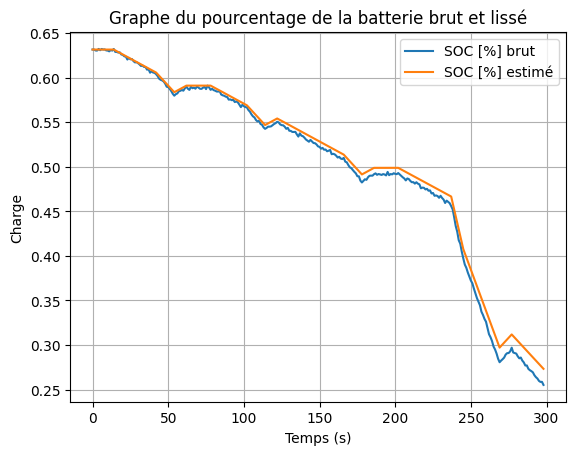

In [5]:
#Affichage du graphe de la batterie
data = pd.read_csv("data_battery.csv")
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data['SOC [%] estimé'] = SOC_estime
data[['SOC [%] brut', 'SOC [%] estimé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()

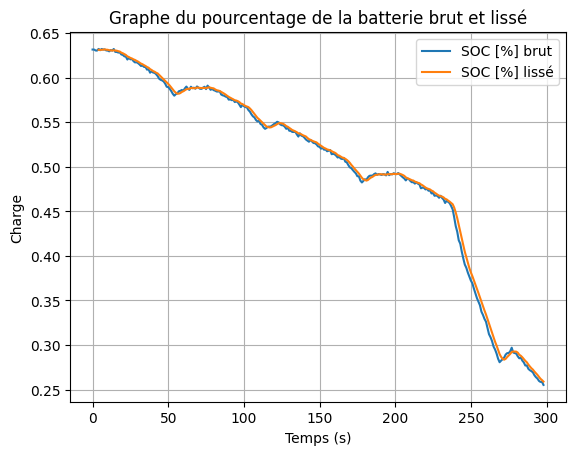

In [6]:
#Affichage du graphe de la batterie
data = pd.read_csv("data_battery.csv")
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data[['SOC [%] brut', 'SOC [%] lissé']].plot(title = "Graphe du pourcentage de la batterie brut et lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge")
plt.grid()
plt.show()